In [1]:
#Ola Bike Ride Request Forecast using ML
#From telling rickshaw-wala where to go, to tell him where to come we have grown up. Yes, we are talking about online cab and bike facility providers like OLA and Uber. 
#If you had used this app some times then you must have paid some day less and someday more for the same journey. But have you ever thought what is the reason behind it? It is because of the high demand at some hours. 
#this is not the only factor but this is one of them.
#Ola Bike Ride Request Forecast using ML
#In this article, we will try to predict ride-request for a particular hour using machine learning. 
#One can refer to the below explanation for the column names in the dataset and their values as well.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error as mae
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\KIIT\Downloads\ola (1).csv")
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


In [4]:
df.shape

(10886, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        9254 non-null   float64
 4   humidity    9254 non-null   float64
 5   windspeed   9254 non-null   float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 765.6+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.493937,1.120531,1.000000,1.000000,2.000000,3.000000,4.000000
weather,10886.0,2.491916,1.123139,1.000000,1.000000,2.000000,4.000000,4.000000
temp,9254.0,23.240116,20.311144,-22.743852,12.470555,20.743790,29.394576,211.102548
humidity,9254.0,124.452421,75.568291,32.713561,87.846187,112.180064,137.301002,672.687236
windspeed,9254.0,34.549616,28.417263,-1.407737,17.963252,30.945593,44.029018,244.921965
casual,10886.0,24.517545,14.390014,0.000000,12.000000,25.000000,37.000000,49.000000
registered,10886.0,99.551442,57.541131,0.000000,50.000000,100.000000,149.000000,199.000000
count,10886.0,224.177267,75.228602,-12.769738,170.140221,224.257587,278.407366,464.839068


In [7]:
#Feature Engineering
#There are times when multiple features are provided in the same feature or we have to derive some features from the existing ones. 
#We will also try to include some extra features in our dataset so, that we can derive some interesting insights from the data we have. 
#Also if the features derived are meaningful then they become a deciding factor in increasing the model's accuracy significantly.

In [8]:
parts = df["datetime"].str.split(" ", n=2, expand=True)
df["date"] = parts[0]
df["time"] = parts[1].str[:2].astype('int')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4


In [9]:
parts = df["date"].str.split("-", n=3, expand=True)
df["day"] = parts[0].astype('int')
df["month"] = parts[1].astype('int')
df["year"] = parts[2].astype('int')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,2011,1,1
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,2011,1,1
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,2011,1,1
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,2011,1,1
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,2011,1,1


In [10]:
from datetime import datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
def weekend_or_weekday(year, month, day):
    try:
        d = datetime(year, month, day)
        return 0 if d.weekday() > 4 else 1
    except ValueError:
        return np.nan 
df['weekday'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0


In [11]:
def am_or_pm(x):
    if x > 11:
        return 1
    else:
        return 0
df['am_or_pm'] = df['time'].apply(am_or_pm)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday,am_or_pm
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0,0


In [12]:
from datetime import date
import holidays
def is_holiday(x):
    india_holidays = holidays.country_holidays('IN')
    if india_holidays.get(x):
        return 1
    else:
        return 0
df['holidays'] = df['date'].apply(is_holiday)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,day,month,year,weekday,am_or_pm,holidays
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,1,1,2011,0,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,1,1,2011,0,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,1,1,2011,0,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,1,1,2011,0,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,1,1,2011,0,0,0


In [13]:
df.drop(['datetime', 'date'],
        axis=1,
        inplace=True)

In [14]:
#Exploratory Data Analysis
#EDA is an approach to analyzing the data using visual techniques. 
#It is used to discover trends, and patterns, or to check assumptions with the help of 
#statistical summaries and graphical representations. We have added some features to our 
#dataset using some assumptions. Now let's check what are the relations between different 
#features with the target feature.

In [15]:
df.isnull().sum()

season           0
weather          0
temp          1632
humidity      1632
windspeed     1632
casual           0
registered       0
count            0
time             0
day              0
month            0
year             0
weekday          0
am_or_pm         0
holidays         0
dtype: int64

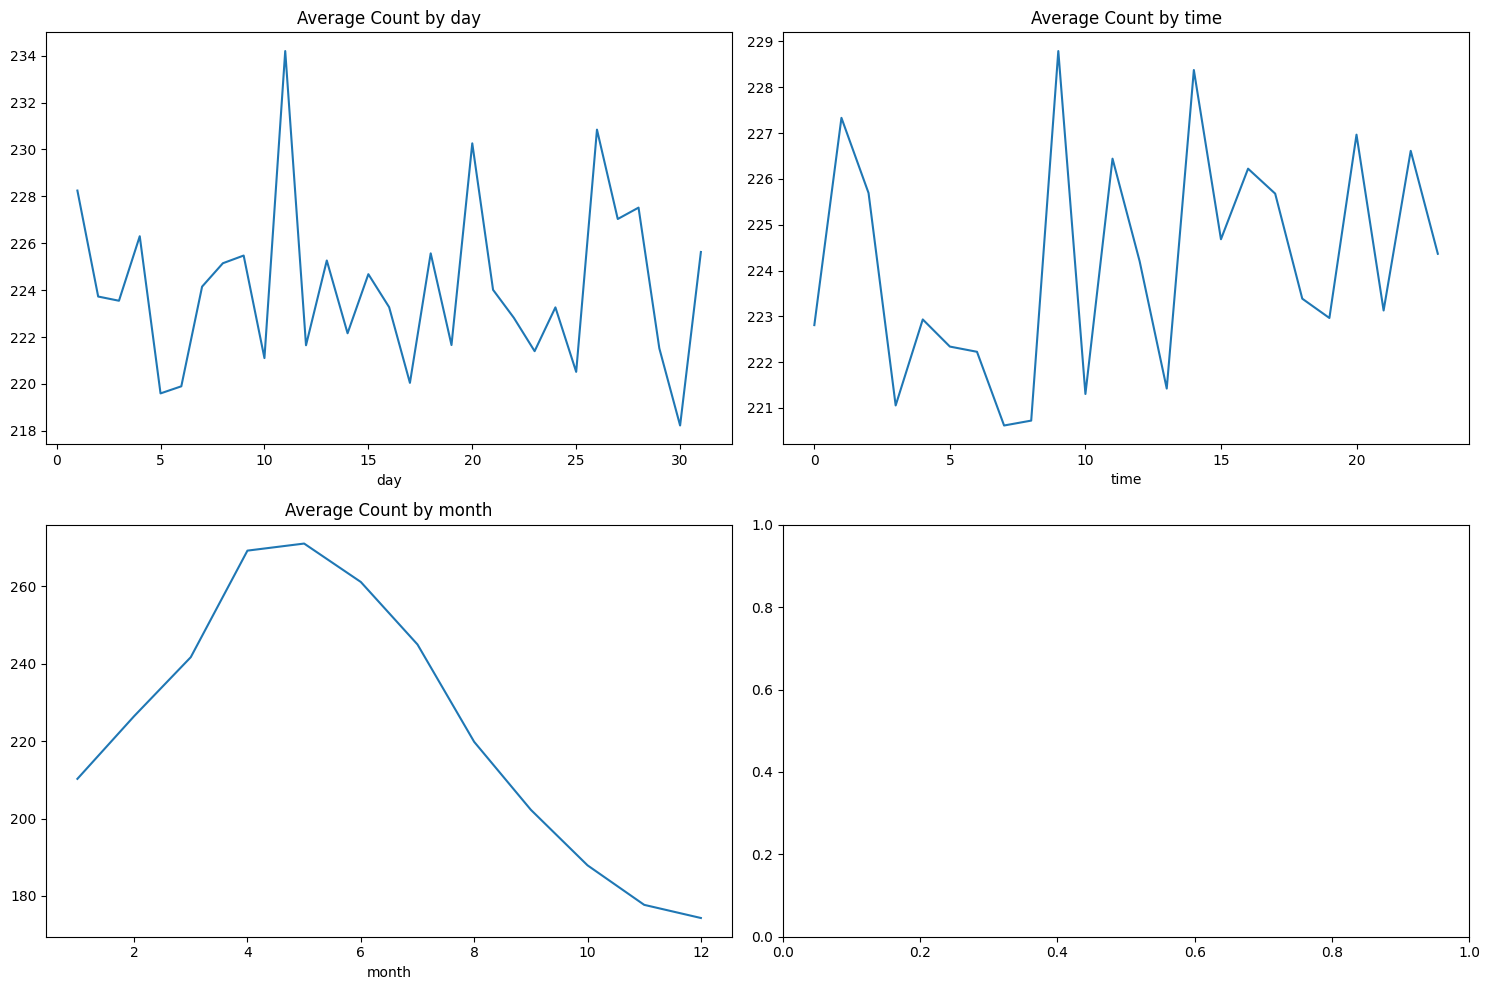

In [17]:
import matplotlib.pyplot as plt
features = ['day', 'time', 'month']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    df.groupby(col)['count'].mean().plot(ax=axes[i])
    axes[i].set_title(f'Average Count by {col}')
plt.tight_layout()
plt.show()

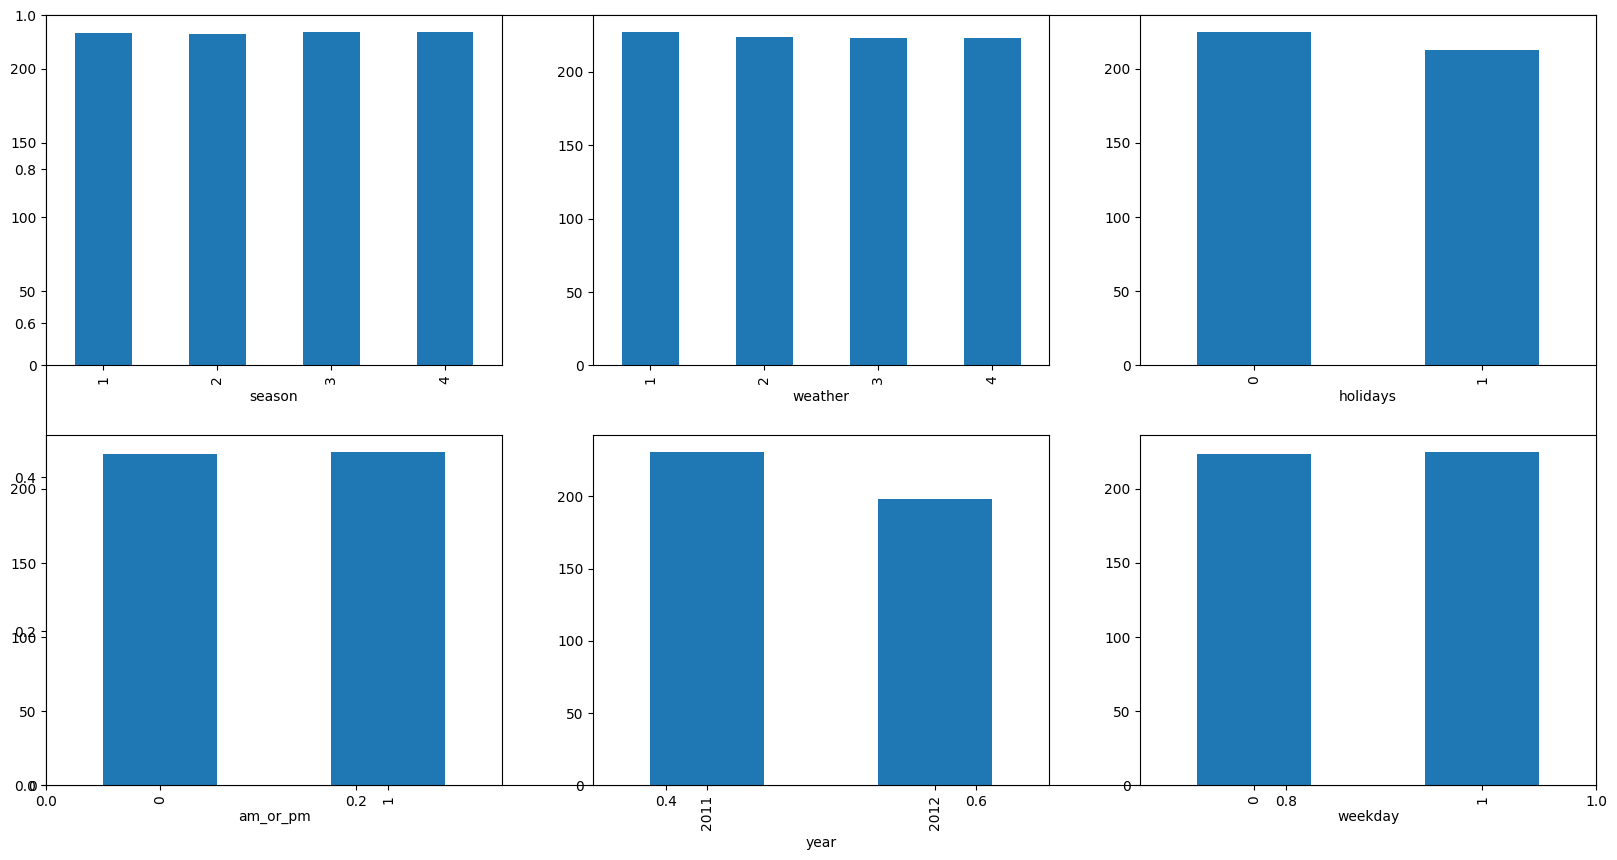

In [18]:
features = ['season', 'weather', 'holidays',\
            'am_or_pm', 'year', 'weekday']
plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

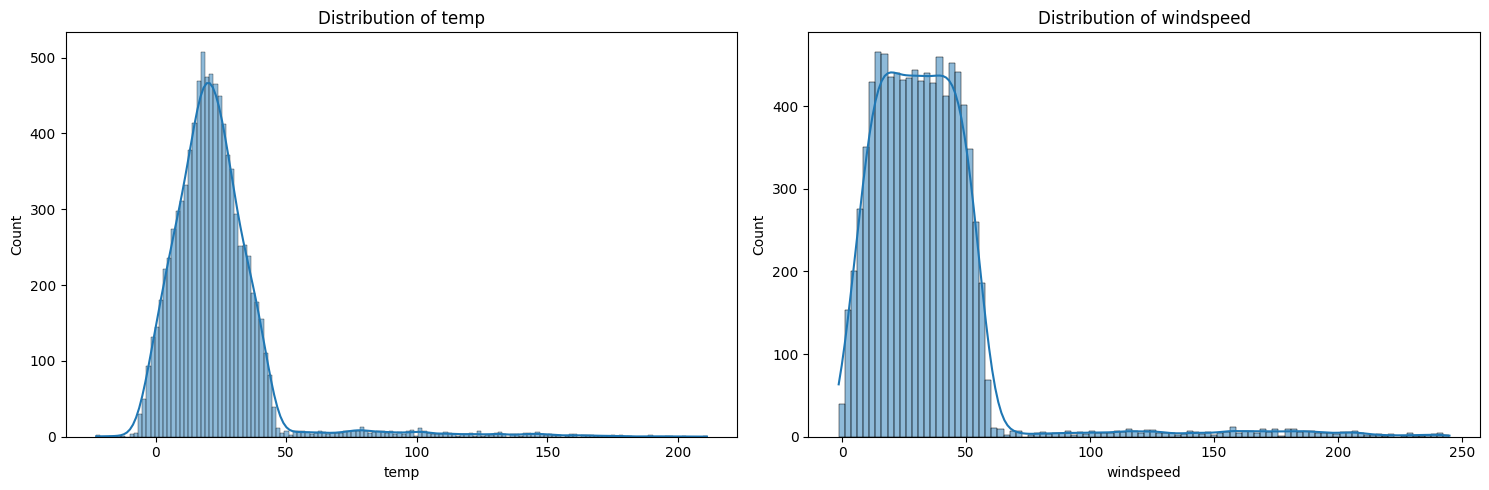

In [21]:
import seaborn as sb
import matplotlib.pyplot as plt
features = ['temp', 'windspeed']
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sb.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

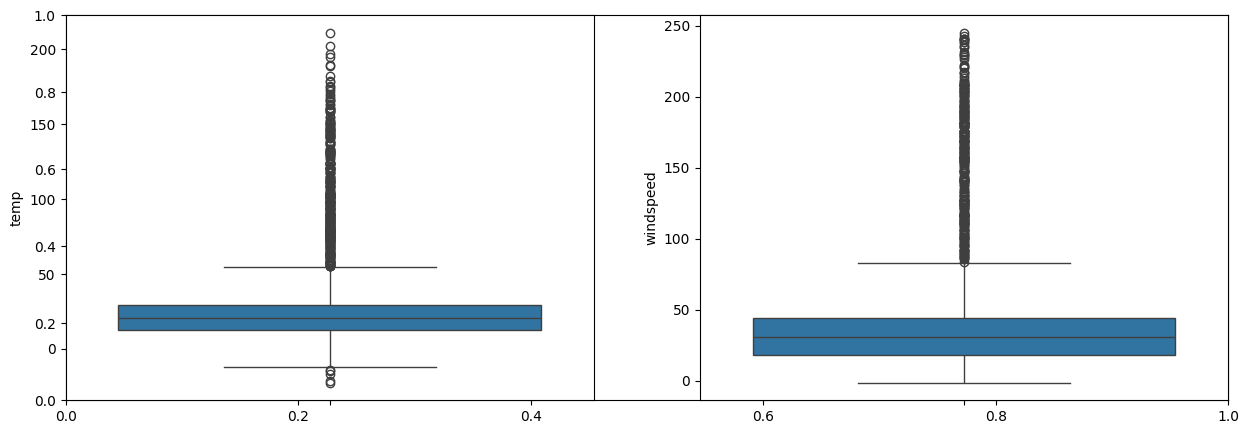

In [22]:
features = ['temp', 'windspeed']
plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sb.boxplot(df[col])
plt.show()

In [23]:
num_rows = df.shape[0] - df[df['windspeed']<32].shape[0]
print(f'Number of rows that will be lost if we remove outliers is equal to {num_rows}.')

Number of rows that will be lost if we remove outliers is equal to 6091.


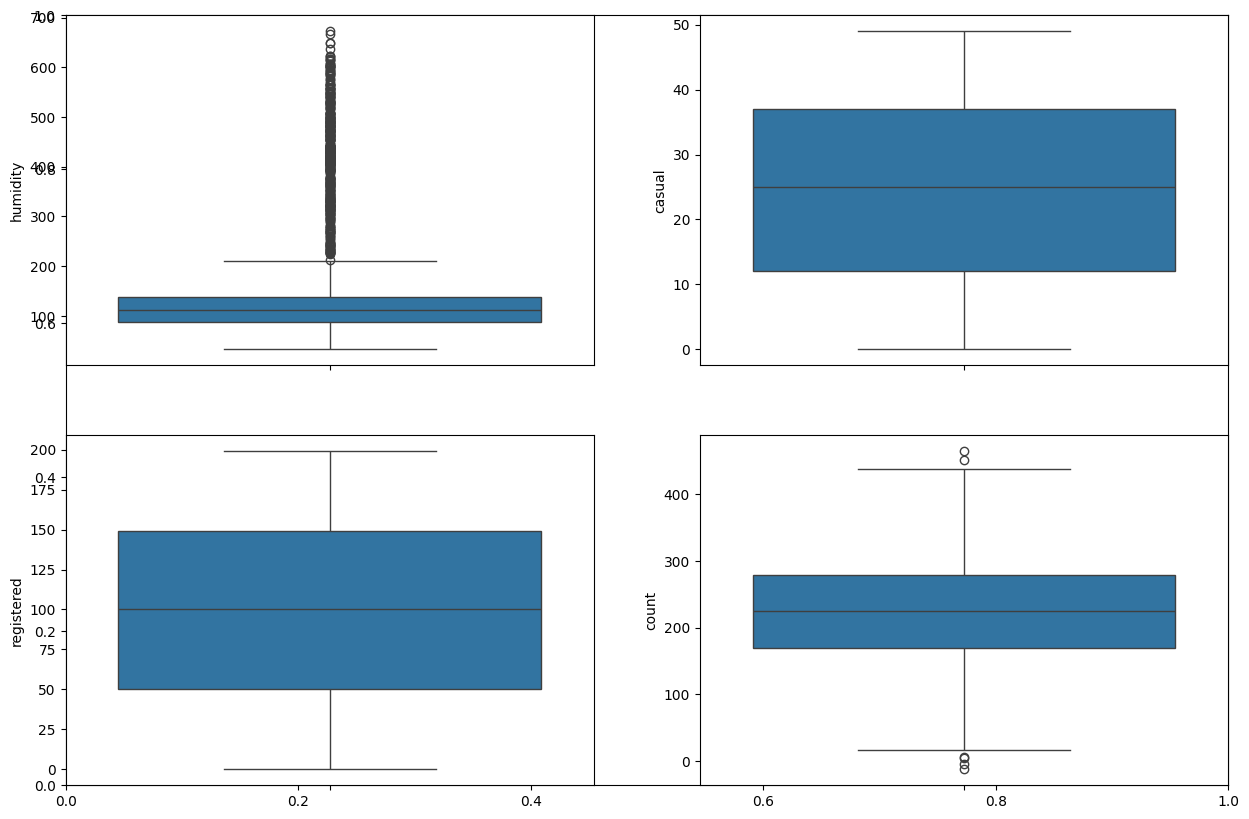

In [24]:
features = ['humidity', 'casual', 'registered', 'count']
plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sb.boxplot(df[col])
plt.show()

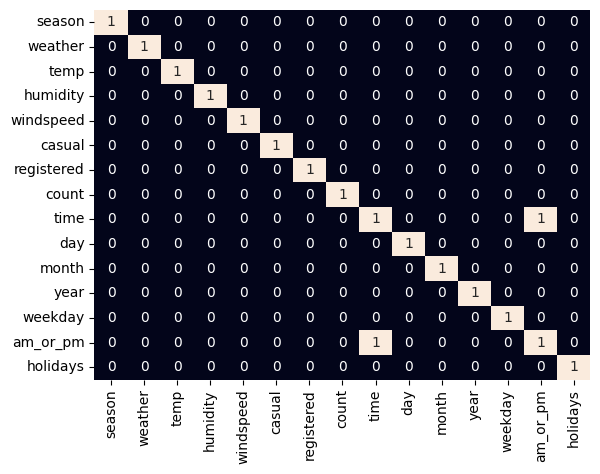

In [25]:
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [26]:
df.drop(['registered', 'time'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

In [36]:
from sklearn.model_selection import train_test_split

features = df.drop(['count'], axis=1)
target = df['count'].values

# ✅ Correct version - opening ( is on the SAME LINE
X_train, X_val, Y_train, Y_val = train_test_split(
    features,
    target,
    test_size=0.1,
    random_state=22
)

print(X_train.shape, X_val.shape)
print("✅ Data split successful!")

(4315, 12) (480, 12)
✅ Data split successful!


In [37]:
# === ADD THIS IMPORT (run once) ===
from sklearn.preprocessing import StandardScaler

# === SCALING ===
scaler = StandardScaler()

# Fit on training data only, then transform both
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print("✅ Scaling completed!")
print("New shapes →", X_train.shape, X_val.shape)

✅ Scaling completed!
New shapes → (4315, 12) (480, 12)


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae

# Assuming your dataframe 'df' is already loaded
features = df.drop(['count'], axis=1)
target = df['count'].values

X_train, X_val, Y_train, Y_val = train_test_split(
    features,
    target,
    test_size=0.1,
    random_state=22
)

print("✅ Split successful!")
print(X_train.shape, X_val.shape)

✅ Split successful!
(4315, 12) (480, 12)


In [35]:
models = [
    LinearRegression(),
    Lasso(),
    RandomForestRegressor(random_state=22),
    Ridge()
]

for model in models:
    model.fit(X_train, Y_train)
    
    print(f"{type(model).__name__} :")
    
    # Training error
    train_preds = model.predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))
    
    # Validation error
    val_preds = model.predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print('=' * 60)
    print()

LinearRegression :
Training Error :  55.518922178324694
Validation Error :  55.74584189664012

Lasso :
Training Error :  55.57358502908425
Validation Error :  56.05994537210243

RandomForestRegressor :
Training Error :  20.514560833239855
Validation Error :  54.89344842531296

Ridge :
Training Error :  55.5187362949681
Validation Error :  55.749270563744254

